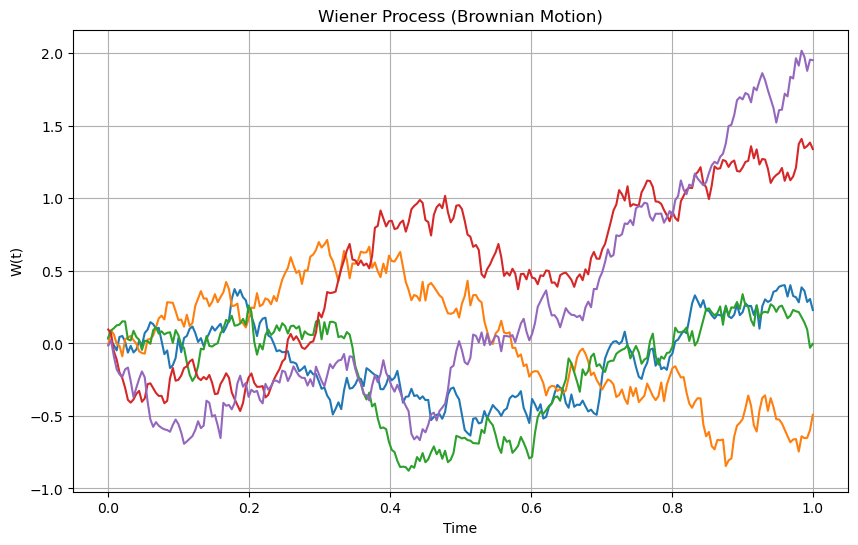

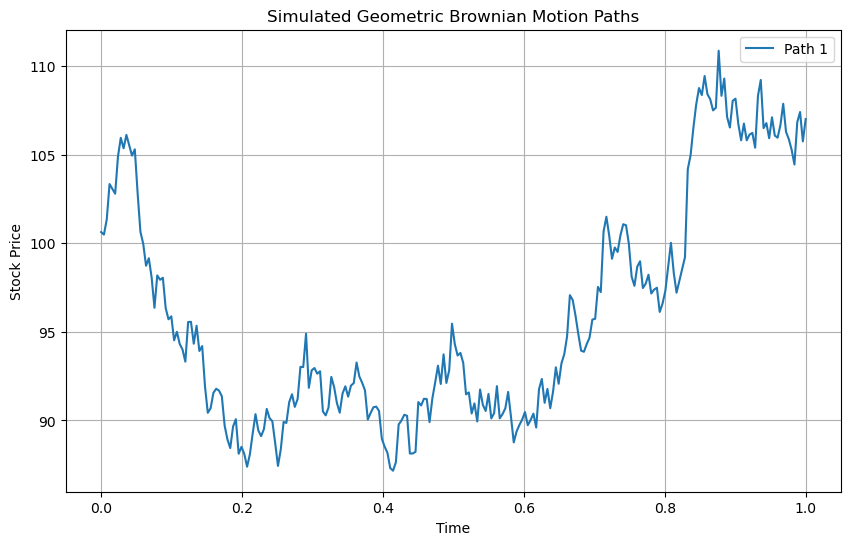

(252, 1)


In [2]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt 
from stock_simulator import gbm

In [26]:
def rolling_volatility(prices, window_size, path=0, annualize=True):
    '''Calculate rolling volatility for a given price series.
    Parameters:
    prices: dataframe of price data
    window_size: int, size of the rolling window
    path: int, index of the path to analyze (for multi-path data) using first path by default
    annualize: bool, whether to annualize the volatility
    Returns:
    pandas dataframe of rolling volatility values
    '''
    if prices.shape[1] > 1 and path is None:
        volatility = pd.DataFrame()
        for i in range(prices.shape[1]):
            prices_path = prices[:, i]
            price_series = pd.Series(np.diff(np.log(prices_path)).flatten())
            volatility[f"Path {i}"] = price_series.rolling(window_size).std() * np.sqrt(252)
        volatility = volatility.dropna()
        if not annualize:
            volatility /= np.sqrt(252)
        return volatility
    if path is not None and (path < 0 or path >= prices.shape[1]):
        raise ValueError("Path index out of bounds.")
    if path is not None:
        prices = prices[f"Path_{path}"].values.reshape(-1, 1)
    price_series = pd.Series(np.diff(np.log(prices),axis=0).flatten())
    volatility = price_series.rolling(window_size).std() * np.sqrt(252)
    volatility = pd.DataFrame({'Volatility': volatility})
    volatility = volatility.dropna()
    if not annualize:
        volatility /= np.sqrt(252)
    return volatility

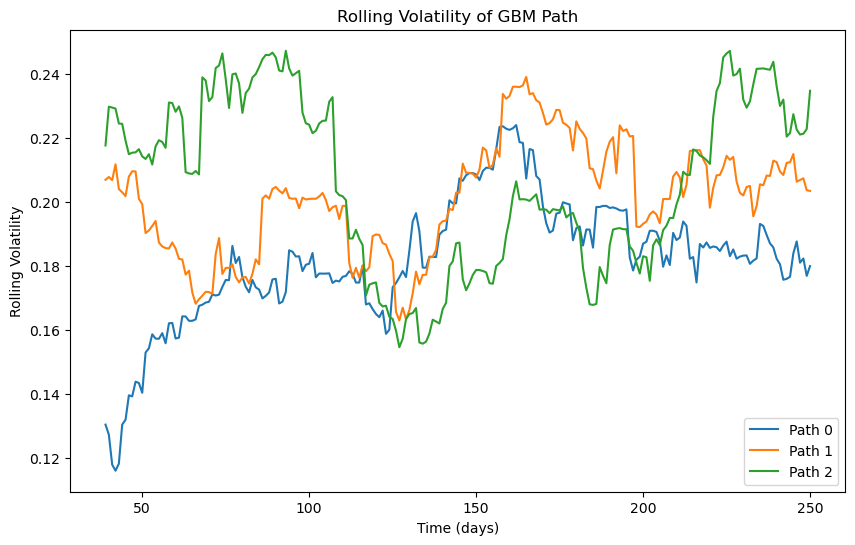

In [31]:
#Create a sample path of the geometric brownian motion to calculate the rolling volatility
gbm_paths, times = gbm(n_paths=3)
rolling_volatility_values = rolling_volatility(gbm_paths, window_size=40, path = None)
rolling_volatility_values.plot(figsize=(10, 6))
plt.title("Rolling Volatility of GBM Path") 
plt.xlabel("Time (days)")
plt.ylabel("Rolling Volatility")
plt.show()

In [32]:
rolling_volatility_values.head()

,Path 0,Path 1,Path 2
39,0.130299,0.206820,0.217552
40,0.127178,0.207702,0.229679
41,0.117789,0.206726,0.229399
42,0.115890,0.211680,0.229070
43,0.118103,0.203923,0.224415


In [29]:
type(rolling_volatility_values)

pandas.core.frame.DataFrame